In [1]:
import pandas as pd

In [2]:
train = pd.read_csv('../data/processed/train.csv')
test = pd.read_csv('../data/processed/test.csv')


In [3]:
train.head()

,property_type,room_type,accommodates,bathrooms,city,host_identity_verified,host_response_rate,neighbourhood,review_scores_rating,bedrooms,has_response_rate,amenity_count,price_per_bed,is_entire_home,listing_density,price_relative_to_room_type,log_price,log_number_of_reviews,rating_category
0,Apartment,Private room,2.0,1.0,New York,False,100.0,Park Slope,4.90,1.0,1,51,100.0,0,481,0.543825,4.615121,2.397895,High Rating
1,House,Private room,1.0,1.0,Los Angeles,True,100.0,Hollywood,5.00,1.0,0,23,62.0,0,1072,-0.145020,4.143135,1.098612,Very High Rating
2,Apartment,Private room,2.0,1.0,New York,True,100.0,Sunset Park,4.85,1.0,1,11,72.0,0,115,0.036255,4.290459,3.850148,High Rating
3,House,Private room,2.0,1.0,Los Angeles,True,100.0,South LA,4.55,1.0,1,14,45.0,0,163,-0.453188,3.828641,2.302585,High Rating
4,House,Private room,1.0,1.0,Boston,True,100.0,Mission Hill,5.00,1.0,0,12,30.0,0,48,-0.725101,3.433987,1.098612,Very High Rating


In [4]:
test.head()

,property_type,room_type,accommodates,bathrooms,city,host_identity_verified,host_response_rate,neighbourhood,review_scores_rating,bedrooms,has_response_rate,amenity_count,price_per_bed,is_entire_home,listing_density,price_relative_to_room_type,log_price,log_number_of_reviews,rating_category
0,Apartment,Private room,1.0,1.0,Boston,True,100.0,Allston-Brighton,5.00,1.0,1,25,40.0,0,334,-0.543825,3.713572,1.791759,Very High Rating
1,Other,Entire home/apt,4.0,1.0,Boston,False,100.0,South End,4.50,0.0,1,21,165.0,1,215,0.042489,5.111988,1.609438,Medium Rating
2,House,Private room,2.0,1.0,Los Angeles,True,100.0,Cahuenga Pass,5.00,1.0,1,26,75.0,0,64,0.090638,4.330733,2.484907,Very High Rating
3,Apartment,Entire home/apt,2.0,1.0,Chicago,True,100.0,Lakeview,4.85,1.0,0,17,129.0,1,224,-0.176028,4.867534,2.564949,High Rating
4,Apartment,Entire home/apt,4.0,1.0,New York,True,100.0,Chelsea,4.80,1.0,0,14,45.0,1,569,-0.412755,4.510860,3.433987,High Rating


In [5]:
train['rating_category'].value_counts()

rating_category
High Rating         18520
Very High Rating    13690
Medium Rating        8482
Name: count, dtype: int64

In [6]:
test['rating_category'].value_counts()

rating_category
High Rating         3969
Very High Rating    2933
Medium Rating       1818
Name: count, dtype: int64

In [7]:
featured = pd.read_csv('../data/processed/featured.csv')
featured.head()

,id,property_type,room_type,amenities,accommodates,bathrooms,city,host_identity_verified,host_response_rate,latitude,...,amenity_count,price_per_bed,price_per_guest,is_entire_home,listing_density,price_relative_to_room_type,price_relative_to_city,log_price,log_number_of_reviews,rating_category
0,6901257,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3.0,1.0,New York,True,100.0,40.696524,...,9,150.000000,50.000000,1,83,-0.048559,0.339332,5.017280,1.098612,Very High Rating
1,6304928,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7.0,1.0,New York,False,100.0,40.766115,...,15,56.333333,24.142857,1,1060,0.066769,0.492839,5.135798,1.945910,High Rating
2,7919400,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5.0,1.0,New York,True,100.0,40.808110,...,19,48.333333,29.000000,1,1075,-0.078909,0.298935,4.983607,2.397895,High Rating
3,12422935,Apartment,Private room,"{TV,""Wireless Internet"",Heating,""Smoke detecto...",2.0,1.0,San Francisco,True,100.0,37.753164,...,10,85.000000,42.500000,0,266,0.271913,-0.428131,4.454347,1.386294,Very High Rating
4,11825529,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",3.0,1.0,Los Angeles,False,100.0,33.980454,...,21,83.000000,27.666667,1,5080,-0.455244,-0.104816,4.430817,2.772589,High Rating


In [8]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
sns.set_style("whitegrid")

print("Libraries loaded successfully")

Libraries loaded successfully


## Feature Overview & Data Types

In [9]:
# Dataset shape and basic info
print("="*70)
print("FEATURED DATASET OVERVIEW")
print("="*70)
print(f"\nShape: {featured.shape}")
print(f"Total rows: {featured.shape[0]:,}")
print(f"Total columns: {featured.shape[1]}")

print("\n" + "="*70)
print("DATA TYPES")
print("="*70)
print(featured.dtypes)

FEATURED DATASET OVERVIEW

Shape: (58132, 26)
Total rows: 58,132
Total columns: 26

DATA TYPES
id                               int64
property_type                   object
room_type                       object
amenities                       object
accommodates                   float64
bathrooms                      float64
city                            object
host_identity_verified            bool
host_response_rate             float64
latitude                       float64
longitude                      float64
neighbourhood                   object
review_scores_rating           float64
bedrooms                       float64
price                          float64
has_response_rate                int64
amenity_count                    int64
price_per_bed                  float64
price_per_guest                float64
is_entire_home                   int64
listing_density                  int64
price_relative_to_room_type    float64
price_relative_to_city         float64
log_pric

## Cardinality Analysis

Identify features with very high (too specific) or very low (constant) cardinality.

In [10]:
# Calculate cardinality for all features
print("="*70)
print("CARDINALITY ANALYSIS")
print("="*70)

cardinality_data = []
for col in featured.columns:
    unique_count = featured[col].nunique()
    unique_ratio = unique_count / len(featured)
    cardinality_data.append({
        'Feature': col,
        'Unique_Values': unique_count,
        'Total_Rows': len(featured),
        'Cardinality_Ratio': unique_ratio,
        'Data_Type': str(featured[col].dtype)
    })

cardinality_df = pd.DataFrame(cardinality_data).sort_values('Cardinality_Ratio', ascending=False)

print("\n" + "="*70)
print("VERY HIGH CARDINALITY (>50% unique values)")
print("="*70)
high_cardinality = cardinality_df[cardinality_df['Cardinality_Ratio'] > 0.5]
print(high_cardinality.to_string(index=False))

print("\n" + "="*70)
print("VERY LOW CARDINALITY (<10 unique values)")
print("="*70)
low_cardinality = cardinality_df[cardinality_df['Unique_Values'] < 10]
print(low_cardinality.to_string(index=False))

print("\n" + "="*70)
print("MODERATE CARDINALITY (10-50% unique)")
print("="*70)
moderate_cardinality = cardinality_df[
    (cardinality_df['Cardinality_Ratio'] >= 0.1) & 
    (cardinality_df['Cardinality_Ratio'] <= 0.5)
]
print(moderate_cardinality.to_string(index=False))

CARDINALITY ANALYSIS

VERY HIGH CARDINALITY (>50% unique values)
  Feature  Unique_Values  Total_Rows  Cardinality_Ratio Data_Type
 latitude          58107       58132           0.999570   float64
       id          58106       58132           0.999553     int64
longitude          58103       58132           0.999501   float64
amenities          53489       58132           0.920130    object

VERY LOW CARDINALITY (<10 unique values)
               Feature  Unique_Values  Total_Rows  Cardinality_Ratio Data_Type
          accommodates              7       58132           0.000120   float64
                  city              6       58132           0.000103    object
             room_type              3       58132           0.000052    object
       rating_category              3       58132           0.000052    object
host_identity_verified              2       58132           0.000034      bool
     has_response_rate              2       58132           0.000034     int64
        is

### Interpretation

**Very High Cardinality Features:**
- `id` - Unique identifier (should be dropped for modeling)
- `amenities` - Text field (already extracted to amenity_count)
- `latitude`, `longitude` - Geographic coordinates (high precision)
- `neighbourhood` - Many unique neighborhoods

**Very Low Cardinality Features:**
- `room_type` - 3 categories (Entire/Private/Shared)
- `city` - 6 cities
- `host_identity_verified` - Binary (True/False)
- `rating_category` - 3 classes (target variable)

## Correlation Analysis (Numeric Features)

In [11]:
# Select numeric features for correlation analysis
numeric_features = featured.select_dtypes(include=[np.number]).columns.tolist()

# Remove id and target from correlation analysis
numeric_features = [col for col in numeric_features if col not in ['id', 'review_scores_rating']]

print("="*70)
print("NUMERIC FEATURES FOR CORRELATION ANALYSIS")
print("="*70)
print(f"Total numeric features: {len(numeric_features)}")
print(f"\nFeatures: {numeric_features}")

# Calculate correlation matrix
corr_matrix = featured[numeric_features].corr()
print(f"\nCorrelation matrix shape: {corr_matrix.shape}")

NUMERIC FEATURES FOR CORRELATION ANALYSIS
Total numeric features: 17

Features: ['accommodates', 'bathrooms', 'host_response_rate', 'latitude', 'longitude', 'bedrooms', 'price', 'has_response_rate', 'amenity_count', 'price_per_bed', 'price_per_guest', 'is_entire_home', 'listing_density', 'price_relative_to_room_type', 'price_relative_to_city', 'log_price', 'log_number_of_reviews']

Correlation matrix shape: (17, 17)


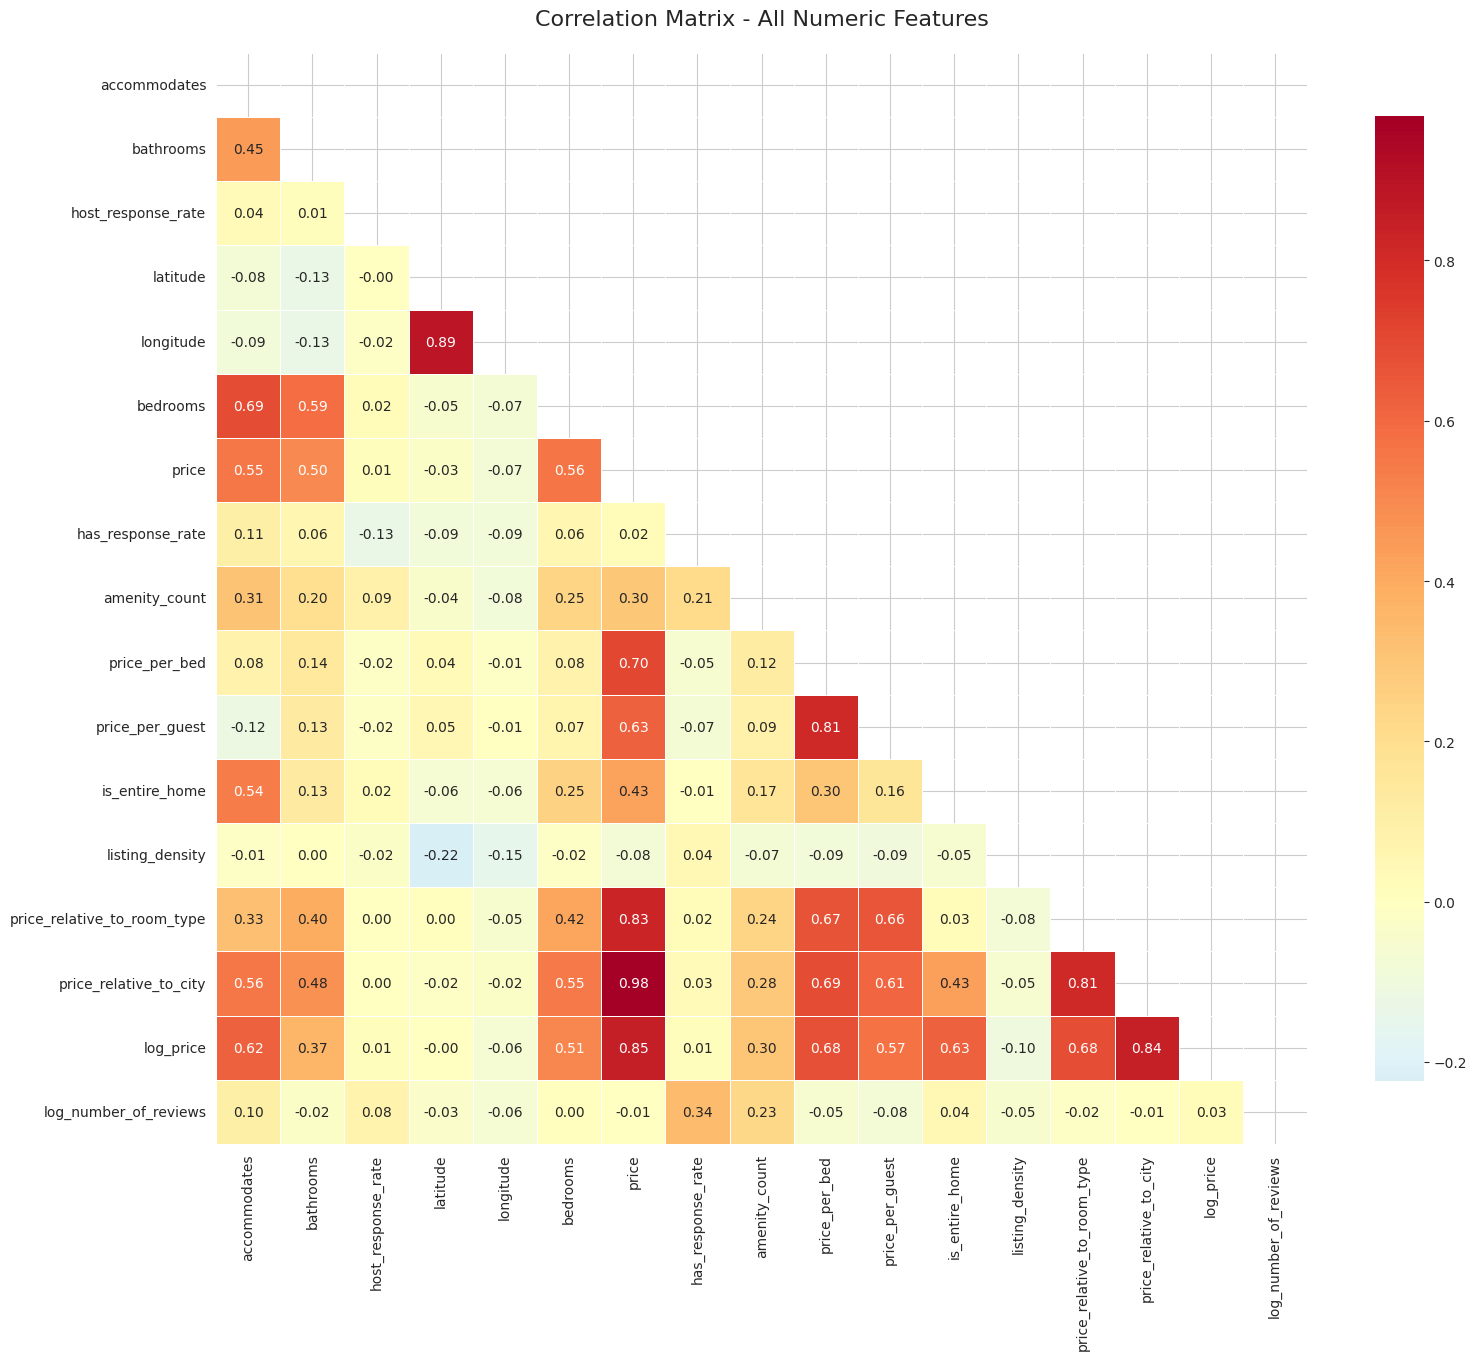

In [12]:
# Visualize correlation matrix
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
plt.figure(figsize=(16, 14))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r', 
            center=0, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
plt.title('Correlation Matrix - All Numeric Features', fontsize=16, pad=20)
plt.tight_layout()
plt.show()

## High Correlation Pairs 

Identify multicollinearity issues

In [13]:
# Find high correlation pairs
print("="*70)
print("HIGH CORRELATION PAIRS (|r| > 0.7)")
print("="*70)

high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        corr_value = corr_matrix.iloc[i, j]
        if abs(corr_value) > 0.7:
            high_corr_pairs.append({
                'Feature_1': corr_matrix.columns[i],
                'Feature_2': corr_matrix.columns[j],
                'Correlation': corr_value
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Correlation', 
                                                              key=abs, 
                                                              ascending=False)
    print(high_corr_df.to_string(index=False))
    
    print(f"\n\nTotal high correlation pairs: {len(high_corr_pairs)}")
    print("\nRECOMMENDATION: Consider dropping one feature from each highly correlated pair")
else:
    print("No high correlation pairs found (|r| > 0.7)")

HIGH CORRELATION PAIRS (|r| > 0.7)
                  Feature_1                   Feature_2  Correlation
                      price      price_relative_to_city     0.980410
                   latitude                   longitude     0.890987
                      price                   log_price     0.852497
     price_relative_to_city                   log_price     0.841393
                      price price_relative_to_room_type     0.833234
              price_per_bed             price_per_guest     0.813488
price_relative_to_room_type      price_relative_to_city     0.813270
                      price               price_per_bed     0.704018


Total high correlation pairs: 8

⚠️  RECOMMENDATION: Consider dropping one feature from each highly correlated pair


## Feature Correlation with Target

Correlation with original continuous target (review_scores_rating)

FEATURE CORRELATION WITH TARGET (review_scores_rating)
amenity_count                  0.154469
price_per_bed                  0.113430
price_per_guest                0.109346
log_price                      0.108782
price_relative_to_room_type    0.092859
price                          0.089655
price_relative_to_city         0.083141
host_response_rate             0.063971
longitude                     -0.059503
latitude                      -0.040981
has_response_rate              0.034730
is_entire_home                 0.030908
bedrooms                       0.023784
bathrooms                      0.020013
listing_density               -0.016712
accommodates                  -0.013917
log_number_of_reviews         -0.012812


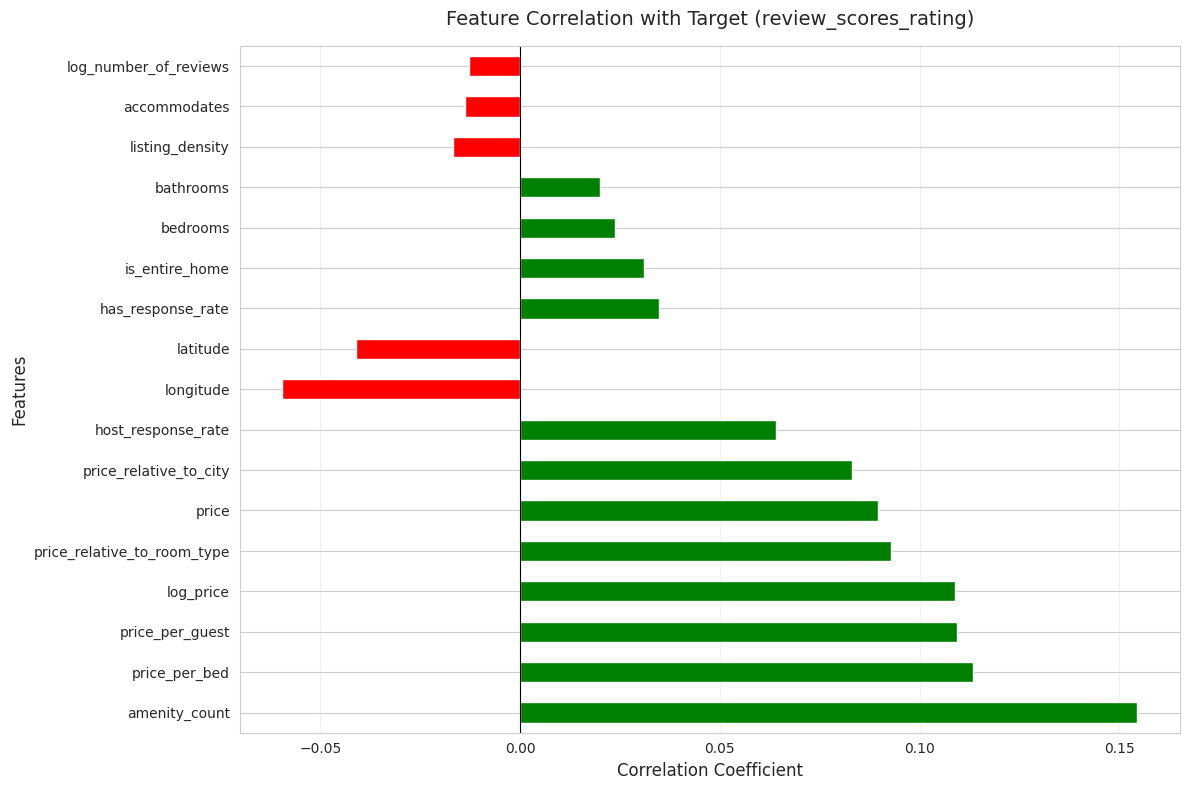


STRONGEST PREDICTORS (|r| > 0.1)
amenity_count      0.154469
price_per_bed      0.113430
price_per_guest    0.109346
log_price          0.108782

⚠️  NOTE: Weak linear correlations suggest non-linear relationships
    → Tree-based models (XGBoost, Random Forest) will perform better than linear models


In [14]:
# Add review_scores_rating to numeric features for target correlation
target_corr_features = numeric_features + ['review_scores_rating']
target_corr = featured[target_corr_features].corr()['review_scores_rating'].drop('review_scores_rating')

# Sort by absolute correlation
target_corr_sorted = target_corr.reindex(target_corr.abs().sort_values(ascending=False).index)

print("="*70)
print("FEATURE CORRELATION WITH TARGET (review_scores_rating)")
print("="*70)
print(target_corr_sorted.to_string())

# Visualize
plt.figure(figsize=(12, 8))
target_corr_sorted.plot(kind='barh', color=['red' if x < 0 else 'green' for x in target_corr_sorted])
plt.xlabel('Correlation Coefficient', fontsize=12)
plt.ylabel('Features', fontsize=12)
plt.title('Feature Correlation with Target (review_scores_rating)', fontsize=14, pad=15)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "="*70)
print("STRONGEST PREDICTORS (|r| > 0.1)")
print("="*70)
strong_predictors = target_corr_sorted[abs(target_corr_sorted) > 0.1]
if len(strong_predictors) > 0:
    print(strong_predictors.to_string())
else:
    print("No features with |r| > 0.1")

## Finally

In [16]:
featured_after_analysis = pd.read_csv('../data/processed/ready_features.csv')
featured_after_analysis.head()

,property_type,room_type,accommodates,bathrooms,city,host_identity_verified,host_response_rate,neighbourhood,review_scores_rating,bedrooms,has_response_rate,amenity_count,price_per_bed,is_entire_home,listing_density,price_relative_to_room_type,log_price,log_number_of_reviews,rating_category
0,Apartment,Entire home/apt,3.0,1.0,New York,True,100.0,Brooklyn Heights,5.00,1.0,0,9,150.000000,1,83,-0.048559,5.017280,1.098612,Very High Rating
1,Apartment,Entire home/apt,7.0,1.0,New York,False,100.0,Hell's Kitchen,4.65,3.0,1,15,56.333333,1,1060,0.066769,5.135798,1.945910,High Rating
2,Apartment,Entire home/apt,5.0,1.0,New York,True,100.0,Harlem,4.60,1.0,1,19,48.333333,1,1075,-0.078909,4.983607,2.397895,High Rating
3,Apartment,Private room,2.0,1.0,San Francisco,True,100.0,Noe Valley,5.00,1.0,1,10,85.000000,0,266,0.271913,4.454347,1.386294,Very High Rating
4,Apartment,Entire home/apt,3.0,1.0,Los Angeles,False,100.0,Unknown,4.85,1.0,1,21,83.000000,1,5080,-0.455244,4.430817,2.772589,High Rating


In [17]:
print(featured.shape)
print(featured_after_analysis.shape)

(58132, 26)
(58132, 19)
